In [ ]:
from langgraph.graph import END, START, StateGraph    # 그래프의 시작/끝 노드, 그래프 빌더
from langgraph.types import Send                      # 병렬 작업을 각 워커에 분배할 때 사용
from typing import TypedDict                          # 딕셔너리 키의 타입을 염시할 때 사용
import subprocess                                     # ffmpeg 같은 외부 명령어를 실행할 때 필요
import os                                             # 환경변수(API 키 등)를 읽어올 때 사용
import base64                                         # 오디오 파일을 API에 전송하기 위해 바이트 -> 문자열 변환
import textwrap                                       # 긴 텍스트를 일정 길이로 잘라줄 때 사용
import operator                                       # operator.add -> 리스트를 합칠 때 쓰는 내장 연산자
import time
import json
from typing_extensions import Annotated               # 타입 힌트에 추가 정보(메타데이터)를 붙일 때 사용
from PIL import Image, ImageDraw, ImageFont           # Pillow 추가  

from langchain.chat_models import init_chat_model
from langchain_google_vertexai import ChatVertexAI
from langchain_google_vertexai.vision_models import VertexAIImageGeneratorChat  
from langchain_core.messages import HumanMessage
from google import genai

import vertexai
from vertexai.preview.vision_models import ImageGenerationModel

# Vertex AI 초기화 (최초 1회)
vertexai.init(project="ai-prompt-evaluator-489612", location="us-central1")

# 1. 텍스트 작업용 모델 (요약 및 프롬프트 생성용)
llm = ChatVertexAI(
  model_name="gemini-2.5-flash-lite",             # 사용할 모델 이름
  max_tokens=500                                  # 응답 최대 길이 (너무 길면 잘림)
)

# 2. 실제 이미지 생성용 모델 (Imagen 3)
# Gemini는 이미지 생성을 지원하지 않으므로 VertexAI의 Imagen 모델을 사용합니다.
imagen_model = ImageGenerationModel.from_pretrained("imagen-3.0-generate-001")

class State(TypedDict):
  video_file: str
  audio_file: str
  transcription: str
  summaries: Annotated[list[str], operator.add]
  thumbnail_prompts: Annotated[list[str], operator.add]
  thumbnail_sketches: Annotated[list[str], operator.add]
  final_summary: str

C:\Users\m1nk1\AppData\Local\Temp\ipykernel_8396\2801340928.py:27: DeprecationWarning: Use [`ChatGoogleGenerativeAI`][langchain_google_genai.ChatGoogleGenerativeAI] instead.
  llm = ChatVertexAI(
C:\Users\m1nk1\AppData\Local\Temp\ipykernel_8396\2801340928.py:27: LangChainDeprecationWarning: The class `ChatVertexAI` was deprecated in LangChain 3.2.0 and will be removed in 4.0.0. An updated version of the class exists in the `langchain-google-genai package and should be used instead. To use it run `pip install -U `langchain-google-genai` and import as `from `langchain_google_genai import ChatGoogleGenerativeAI``.
  llm = ChatVertexAI(
c:\my_study\youtube-thumbnail-maker\.venv\Lib\site-packages\vertexai\_model_garden\_model_garden_models.py:278: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


In [2]:
# ─────────────────────────────────────────
# 노드 1: 영상에서 오디오 추출
# ─────────────────────────────────────────

from langchain_core.messages import content


def extract_audio(state: State):
  """
  ffmpeg를 이용해 mp4 영상에서 mp3 오디오를 추출합니다.
  재생 속도도 2배로 높여서 API 처리량을 줄여줘요 (비용 절감 효과도 있어요!)

  반환값: audio_file 경로를 State에 저장합니다.
  """
  
  # 파일 확장자를 mp4 -> mp3로 바꿔서 출력 파일 이름을 만들어요.
  output_file = state["video_file"].replace("mp4", "mp3")

  # ffmpeg 명령어를 리스트 형태로 구성해요
  # -i: 입력 파일 지정
  # -filter:a "atempo=2.0": 오디오 속도를 2배로 높임 (2배 이상은 2단계로 나눠야 해요)
  # -y: 같은 이름의 파일이 있으면 덮어쓰기 허용
  command = [
    "ffmpeg",
    "-i",
    state["video_file"],
    "-filter:a",
    "atempo=2.0",
    "-y",
    output_file,
  ]

  # subprocess.run()으로 실제 터미널 명령어를 실행해요.
  # ffmpeg -i korea_2.mp4 -filter:a atempo=2.0 -y korea_2.mp3
  subprocess.run(command)

  # 다음 노드에서 사용할 수 있도록 오디오 파일 경로를 State에 저장합니다.
  return {
    "audio_file": output_file
  }


# ─────────────────────────────────────────
# 노드 2: 오디오 → 텍스트 변환 (Transcription)
# ─────────────────────────────────────────

def transcribe_audio(state: State):
  """
  Google GenAI SDK를 사용해 mp3 오디오를 한국어 텍스트로 변홥합니다.
  Gemini 모델에 오디오 파일을 직접 전달해서 음성 인식을 수행해요.
  """

  api_key = os.environ.get("GOOGLE_API_KEY")
  if not api_key:
    raise ValueError(
      "GOOGLE_API_KEY가 없습니다. .env를 채우고 load_dotenv() 호출이 되었는지 확인하세요."
    )

  # GenAI 클라이언트를 API 키로 초기화합니다.
  client = genai.Client(api_key=api_key)

  # 오디오 파일을 바이트로 읽고, base64 문자열로 인코딩합니다.
  # API는 바이너리 파일을 직접 받지 않고, 문자열(base64) 형태로 전달받아요
  with open(state["audio_file"], "rb") as audio_file:
    audio_bytes = audio_file.read()

  audio_b64 = base64.b64encode(audio_bytes).decode("utf-8")

  # Gemini에게 전달할 지시문 (프롬프트)
  prompt = (
    "Trascribe the audio to Korean."
    "This country is the Republic of Korea"
    "Return only the transcription text"
  )

  # Gemini 모델 호출: 텍스트 지시문 + 오디오 데이터를 함께 전달합니다.
  response = client.models.generate_content(
    model="gemini-2.5-flash-lite",
    contents=[
      {
        "role": "user",
        "parts": [
          {"text": prompt},
          {
            "inline_data": {
              "mime_type": "audio/mpeg",  # mp3 파일의 MIME 타입
              "data": audio_b64,          # base64로 인코딩된 오디오 데이터
            }
          },
        ],
      }
    ],
  )

  # 응답에서 텍스트를 안전하게 추출합니다.
  # Gemini SDK 버전에 따라 응답 구조가 다를 수 있어서, 여러 방법으로 시도해요
  transcription = getattr(response, "text", None)
  if not transcription:
    try:
      # response.text가 없을 때 candidates 배열에서 직접 꺼내는 대안 방법
      transcription = response.candidates[0].content.parts[0].text
    except Exception:
      transcription = None

  # 위 두 방법 모두 실해하면 response 전체를 문자열로 변환합니다. (디버깅용)
  if not transcription:
    transcription = str(response)

  return {
    "transcription": transcription,
  }


# ─────────────────────────────────────────
# 조건부 엣지: 텍스트를 청크로 나눠 병렬 처리
# ─────────────────────────────────────────

def dispatch_summarizes(state: State):
  """
  긴 텍스트(전사본)를 500자씩 잘라서 각 청크를 summarize_chunk 노드로 보냅니다.
  LangGraph의 Send()를 사용하면 여러 노드에 동시에 데이터를 보낼 수 있어요 (팬아웃 패턴).

  예: 텍스트가 1500자라면 → 청크 3개를 동시에 처리 → 결과가 summaries에 합쳐져요
  """
  transcription = state["transcription"]
  chunks = []
  
  # textwrap.wrap: 텍스트를 단어 단위로 잘라서 최대 500자짜리 덩어리 리스트를 만들어요
  # i와 잘려진 텍스트 조각(text_chunk)
  for i, text_chunk in enumerate(textwrap.wrap(transcription, 5000)):
    # chunk가 아닌 'chunks' 리스트에 append 합니다.
    chunks.append({
      "id": i + 1,    
      "chunk": text_chunk, 
    })

  # Send("노드이름", 데이터): 해당 노드를 데이터와 함께 실행해줘요.
  # 여러 Send()를 리스트로 반환하면 동시(병렬)에 실행됩니다.  
  return [
    Send("summarize_chunk", chunk_data) for chunk_data in chunks
  ]

# ─────────────────────────────────────────
# 노드 3: 청크 요약
# ─────────────────────────────────────────

def summarize_chunk(chunk):
  """
  각 텍스트 청크를 LLM(Gemini)으로 요약합니다.
  dispatch_summarizers가 나눠준 청크 하나씩 이 함수가 독립적으로 처리해요.

  반환값 "[Chunk N] 요약 내용" 형식의 문자열이 summaries 리스트에 추가됩니다.
  """
  chunk_id = chunk["id"]    # 몇 번째 청크인지
  text_chunk = chunk["chunk"]    # 실제 텍스트 내용

  # LLM에게 요약 요청을 보냅니다.
  response = llm.invoke(
    f"""
    아래 텍스트를 한국어로 간결하게 요약해 주세요.
    반드시 한국어로만 답변하세요.

    Text: {text_chunk}
    """
  )

  # 청크 번호를 앞에 붙여서 어떤 청크의 요약인지 구분하기 쉽게 만들어요.
  summary = f"[Chunk {chunk_id}] {response.content}"

  # summaries는 Annotated[list[str], operator.add] 타입이므로,
  # 리스트 형태로 반환해야 여러 병렬 결과가 자동으로 합쳐져요
  return {
    "summaries": [summary],
  }



In [4]:
def mega_summary(state: State):
  all_summaries = "\\n".join(state["summaries"])

  prompt = f"""
    You are given multiple summaries of different chunks from a video transcription.
    Please create a comprehensive final summary that combines all the key points.
    Individual summaries:
    {all_summaries}
  """
  response = llm.invoke(prompt)

  return {
    "final_summary": response.content,
  }
  

def dispatch_artists(state: State):
  return [
    Send(
      "generate_thumbnails",
      {
        "id": i,
        "summary": state["final_summary"],
      },
    )

    for i in [6, 7]
  ]


def generate_thumbnails(args):
  concept_id = args["id"]
  summary = args["summary"]

  # 1. 텍스트 프롬프트 생성 (gemini-2.5-flash-lite)
  # 1. LLM에게 이미지 프롬프트와 한글 타이틀을 '분리해서' JSON으로 받기
  prompt = f"""
    Based on this video summary, create a YouTube thumbnail concept.
    Return ONLY a valid JSON object with two keys:
    - "thumbnail_title": A catchy, short Korean title for the thumbnail (3-6 words).
    - "image_prompt": A prompt for an image generation model. 
      * IMPORTANT for image_prompt: Describe a scene with a clear focal subject and deliberate EMPTY/NEGATIVE SPACE (top, bottom, or side) for text placement later. DO NOT ask the image generator to draw text. Include dramatic lighting and vibrant colors.

    Summary: {summary}
  """

  prompt_response = llm.invoke(prompt)
  
  try:
    # LLM 응답이 JSON 텍스트라고 가정하고 파싱
    response_data = json.loads(prompt_response.content)
    korean_title = response_data.get("thumbnail_title", "위대한 대한민국")
    thumbnail_prompt = response_data.get("image_prompt", "")
  except Exception:
    # JSON 파싱 실패 시 대비책
    korean_title = "아시아의 중심이자 세계와 교류하는 나라, 대한민국"
    thumbnail_prompt = prompt_response.content

  # 2. Vertex AI Imagen SDK로 이미지 생성 (텍스트 없이 여백만 있는 이미지)
  max_retries = 3
  for attempt in range(max_retries):
      try:
          images = imagen_model.generate_images(
              prompt=thumbnail_prompt,
              number_of_images=1,
              aspect_ratio="16:9",
              safety_filter_level="block_few",
          )
          break
      except Exception as e: # ResourceExhausted 등
          if attempt < max_retries - 1:
              wait_seconds = 30 * (attempt + 1)
              print(f"⚠️ [{concept_id}번] 대기 중... {wait_seconds}초 후 재시도")
              time.sleep(wait_seconds)
          else:
              return {"thumbnail_prompts": [thumbnail_prompt], "thumbnail_sketches": []}

  # 3. 파일로 먼저 임시 저장 (Imagen 객체에서 PIL 객체로 변환하기 위함)
  temp_file_name = f"temp_concept_{concept_id}.png"
  images[0].save(location=temp_file_name, include_generation_parameters=False)

  # 4. Pillow(PIL)를 사용하여 한글 텍스트 합성
  img = Image.open(temp_file_name)
  draw = ImageDraw.Draw(img)
  
  # 폰트 설정 (시스템에 있는 한글 폰트 경로 지정 필요)
  # 예: 윈도우 "C:/Windows/Fonts/malgun.ttf", 맥 "/Library/Fonts/AppleGothic.ttf"
  font_path = "NanumGothicBold.ttf" 
  
  try:
      # 이미지 크기에 맞게 폰트 크기 조절 (예: 16:9 이미지 기준 80)
      font = ImageFont.truetype(font_path, 80)
  except IOError:
      font = ImageFont.load_default()
      print("⚠️ 폰트 파일을 찾을 수 없어 기본 폰트를 사용합니다. 한글이 깨질 수 있습니다.")

  # 텍스트 위치 및 색상 설정 (유튜브 썸네일 스타일의 텍스트 테두리 효과)
  text_position = (50, 50) # 좌측 상단 여백 (조정 필요)
  text_color = (255, 255, 255) # 흰색 텍스트
  outline_color = (0, 0, 0)    # 검은색 테두리
  outline_width = 3

  # 테두리 그리기
  for x_offset in range(-outline_width, outline_width + 1):
    for y_offset in range(-outline_width, outline_width + 1):
      draw.text((text_position[0] + x_offset, text_position[1] + y_offset), 
                korean_title, font=font, fill=outline_color)
  
  # 실제 텍스트 그리기
  draw.text(text_position, korean_title, font=font, fill=text_color)

  # 최종 이미지 저장
  final_file_name = f"thumbnail_concept_{concept_id}.png"
  img.save(final_file_name)
  print(f"✅ {final_file_name} 저장 및 텍스트 합성 완료!")

  # 5. State 반환용 base64 변환
  with open(final_file_name, "rb") as f:
    image_b64 = base64.b64encode(f.read()).decode("utf-8")
  
  image_base64_url = f"data:image/png;base64,{image_b64}"
  
  return {
    "thumbnail_prompts": [thumbnail_prompt],
    "thumbnail_sketches": [image_base64_url],
    "thumbnail_korean_title": korean_title # 참조용으로 State에 추가
  }

In [5]:
graph_builder = StateGraph(State)

graph_builder.add_node("extract_audio", extract_audio)
graph_builder.add_node("transcribe_audio", transcribe_audio)
graph_builder.add_node("summarize_chunk", summarize_chunk)
graph_builder.add_node("mega_summary", mega_summary)
graph_builder.add_node("generate_thumbnails", generate_thumbnails)

graph_builder.add_edge(START, "extract_audio")
graph_builder.add_edge("extract_audio", "transcribe_audio")
graph_builder.add_conditional_edges(
    "transcribe_audio", dispatch_summarizes, ["summarize_chunk"]  # ✅ 함수명 수정
)
graph_builder.add_edge("summarize_chunk", "mega_summary")
graph_builder.add_conditional_edges(
    "mega_summary", dispatch_artists, ["generate_thumbnails"]
)
graph_builder.add_edge("generate_thumbnails", END)

graph = graph_builder.compile()

c:\my_study\youtube-thumbnail-maker\.venv\Lib\site-packages\vertexai\vision_models\_vision_models.py:1437: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()
c:\my_study\youtube-thumbnail-maker\.venv\Lib\site-packages\vertexai\vision_models\_vision_models.py:154: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


⚠️ 폰트 파일을 찾을 수 없어 기본 폰트를 사용합니다. 한글이 깨질 수 있습니다.
✅ thumbnail_concept_6.png 저장 및 텍스트 합성 완료!
⚠️ 폰트 파일을 찾을 수 없어 기본 폰트를 사용합니다. 한글이 깨질 수 있습니다.
✅ thumbnail_concept_7.png 저장 및 텍스트 합성 완료!


{'video_file': 'korea_2.mp4',
 'audio_file': 'korea_2.mp3',
 'transcription': '기적의 나라\n저력의 나라\n1950년 전쟁으로 폐허가 된 땅\n세상에서 가장\n간절한 나라\n전쟁으로 폐허가 된 이 나라가\n다시 원래의 모습을 찾기 위해서는\n100년이 걸릴 것이다\n35년간 일본의 식민지\n남북한 이념 대립의\n이제는 전쟁까지 하는 이 나라가\n재발로 서기를 바라노니\n쓰레기 더미에서 장미꽃이 피는 것을 바라겠다\n하지만 이 나라는\n세계 2차 대전 후 독립한 80여 개 나라 중에서\n유일하게 수준의 경제 성장과 민주주의를\n동시에 달성한 유일한 나라로 성장했다\n2019년 식민지를 경험한 국가로서\n최초로 1인당 국민소득 3만 달러\n인구 5천만 이상만 가입되는 3050 클럽\n사람들은 이야기합니다\n선진국이 300년에 걸쳐 이룩한 경제 발전\n민주화를 불과 반세기만에 성취한\n이 나라의 역사는\n현대 인류 역사의 기적이라고\n하지만 이 나라 사람들은 말합니다\n이 나라의 성취는 우연히 일어난 기적이 아니라\n바로 오랜 역사의 토양 위에 자란 저력이라고\n전통의 나라\n창조의 나라\n이 나라는 5천 년의 역사 속에\n500년 이상 지속된 왕조가 여러 번 등장하는\n전통의 나라\n대한민국 이전 조선 왕조 500년\n조선 왕조 이전 고려 왕조 500년\n고려 왕조 이전 신라 1000년\n신라 이전 고구려 700년 백제 700년\n기원전 2333년\n이 나라 최초 한국을 보존한 꿈\n홍익인간\n세계를 변화시키는 나라\n이 나라는 유구한 전통의 역사 속에서\n세계 유일의 창조를 만들어냈습니다\n1377년\n금속 활자로 만든 책 직지\n이 나라는 1천년 동안 인류를 바꾸는 가장 위대한 발명으로\n높이는 금속 활자 서라보다 먼저 창조해 책을 인쇄하고 보급\n1443년\n이 나라의 최고 통치자 세종대왕\n자신의 백성을 사랑해서 직접 문자를 창조\n세계 최고 수준의 과학적인 창조물로 평가받는\n이 나라의 문자는
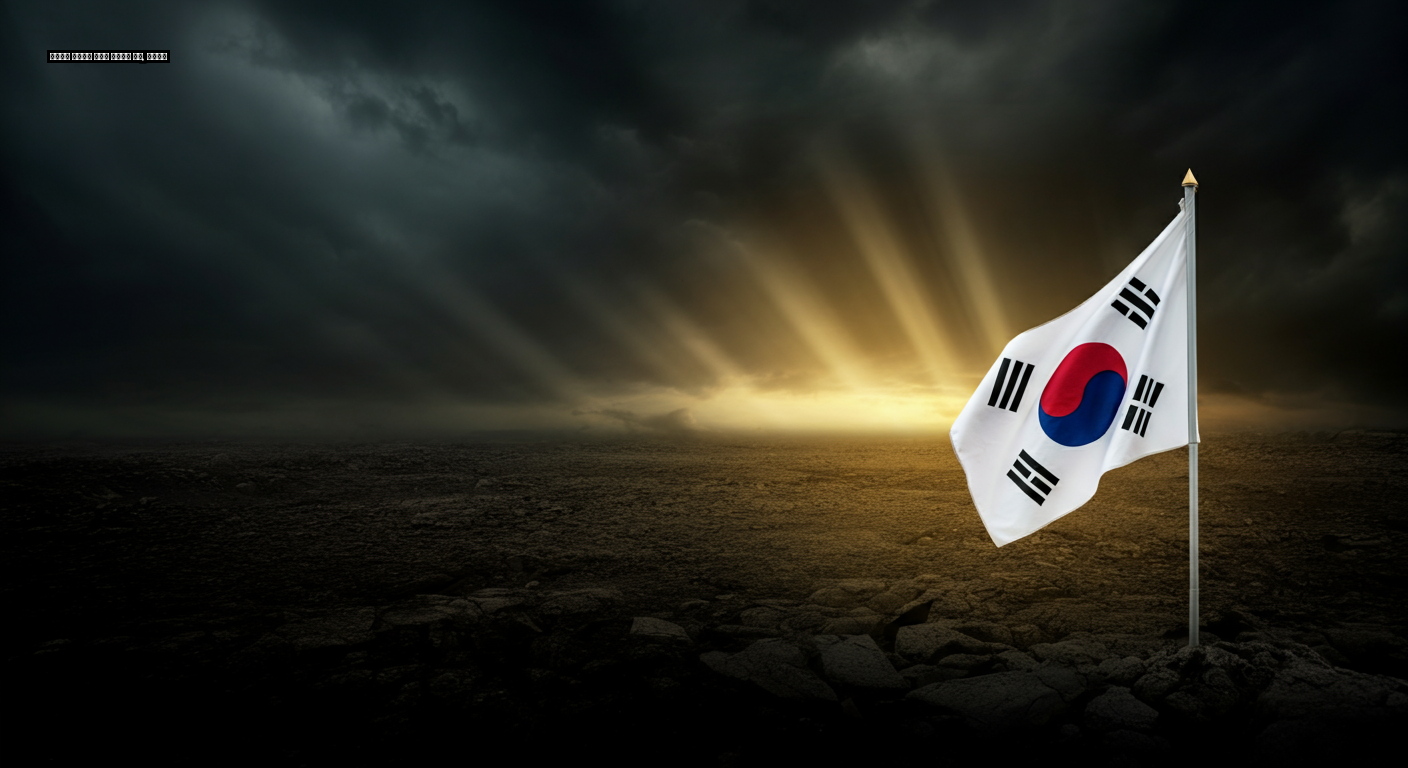
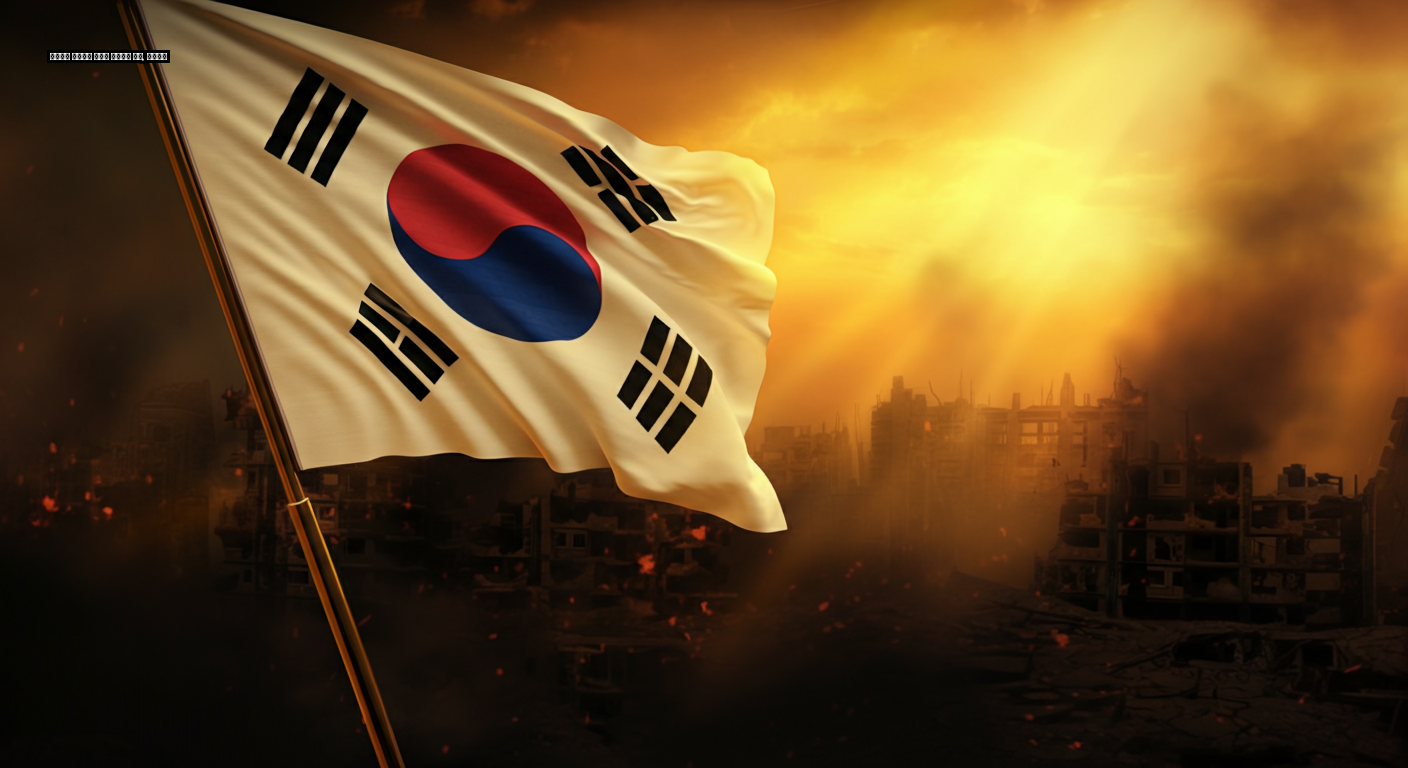

In [6]:
graph.invoke({
    "video_file": "korea_2.mp4"
})

In [ ]:
response = {
  "user_feedback": "Make sure the fella is smiling, remove any mention of audible, or any logo, and give it a photo realistic, 3d style.",
  "chosen_prompt": 1,
}

graph.invoke(
  Command(resume=response),
  config=config  
)